## Notebook 05 — Temporal Reinforcement in Logged Feeds (MIND-small)

I test a very specific “echo chamber / reinforcement” idea using the **logged** recommendation lists:

> **If a user clicks political content, do the *next* recommendation lists shown to that user contain *more* political content?**

The ideia is just to see how the recommendations from the MIND dataset behaved throughout time and user interactions.

The real recommender is **not** controled here. I use the logs:
- Each **impression** = one moment a user was shown a list of candidate news.
- The log tells me which candidates were shown and which were clicked.

### Outputs
1. **One-step effect**: difference in next-impression political exposure after a political click vs after a non-political click.
2. **Lag curve (1–10 impressions)**: does the effect persist?
3. Split by user group:
   - **Politically engaged** (≥3 political clicks in TRAIN)
   - Everyone else
4. A **within-user** version (reduces confounding from stable user differences).

**Note:** Observational evidence (not a controlled causal experiment).


### Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Path

In [2]:
PROJECT = Path().resolve().parent
PROCESSED = PROJECT / "data" / "processed"

print("PROJECT:", PROJECT)
print("PROCESSED:", PROCESSED)
print("Exists?", PROCESSED.exists())
print("Files:", [p.name for p in PROCESSED.iterdir()] if PROCESSED.exists() else "MISSING")

PROJECT: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project
PROCESSED: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project\data\processed
Exists? True
Files: ['clicks_dev.pkl', 'clicks_train.pkl', 'news_dev.pkl', 'news_train.pkl']


### Load TRAIN + DEV tables

**TRAIN is used only to define “politically engaged” users** (≥3 political clicks).  
**DEV is used to test temporal reinforcement** in chronological logs.

In [3]:
clicks_train = pd.read_pickle(PROCESSED / "clicks_train.pkl")
news_train   = pd.read_pickle(PROCESSED / "news_train.pkl")

clicks_dev = pd.read_pickle(PROCESSED / "clicks_dev.pkl")
news_dev   = pd.read_pickle(PROCESSED / "news_dev.pkl")

print("train clicks:", clicks_train.shape, "train news:", news_train.shape)
print("dev clicks:", clicks_dev.shape, "dev news:", news_dev.shape)
display(clicks_dev.head(3))

train clicks: (5843444, 9) train news: (51282, 8)
dev clicks: (2740998, 9) dev news: (42416, 8)


,impression_id,user_id,time,history,news_id,clicked,category,subcategory,title
0,1,U80234,11/15/2019 12:37:50 PM,N55189 N46039 N51741 N53234 N11276 N264 N40716...,N28682,0,sports,football_nfl,"Browns apologize to Mason Rudolph, call Myles ..."
1,1,U80234,11/15/2019 12:37:50 PM,N55189 N46039 N51741 N53234 N11276 N264 N40716...,N48740,0,lifestyle,voices,I've been writing about tiny homes for a year ...
2,1,U80234,11/15/2019 12:37:50 PM,N55189 N46039 N51741 N53234 N11276 N264 N40716...,N31958,1,sports,football_nfl,Opinion: Colin Kaepernick is about to get what...


### Define `is_politics` for each candidate row
This does not have ideology in consideration yet (left/center/right comes later).

In [4]:
def ensure_politics_flag(clicks_df, news_df, subcategory_col="subcategory"):
    # Ensure clicks_df has a boolean is_politics.
    clicks_df = clicks_df.copy()

    if subcategory_col in clicks_df.columns:
        clicks_df["is_politics"] = clicks_df[subcategory_col].astype(str).str.contains("polit", case=False, na=False)
        return clicks_df

    # fallback: merge from news_df
    tmp = news_df[["news_id", subcategory_col]].copy()
    tmp[subcategory_col] = tmp[subcategory_col].astype(str)
    tmp["is_politics"] = tmp[subcategory_col].str.contains("polit", case=False, na=False)

    clicks_df = clicks_df.merge(tmp[["news_id", "is_politics"]], on="news_id", how="left")
    clicks_df["is_politics"] = clicks_df["is_politics"].fillna(False).astype(bool)
    return clicks_df

clicks_train = ensure_politics_flag(clicks_train, news_train)
clicks_dev   = ensure_politics_flag(clicks_dev, news_dev)

print("Train politics exposure share:", clicks_train["is_politics"].mean())
print("Dev politics exposure share:", clicks_dev["is_politics"].mean())
print("Dev politics click share:", clicks_dev.loc[clicks_dev["clicked"]==1, "is_politics"].mean())


Train politics exposure share: 0.04470206268768897
Dev politics exposure share: 0.049444399448667964
Dev politics click share: 0.04275338247308835


### Define “politically engaged” users (TRAIN only)

In [5]:
pol_clicks_per_user = (
    clicks_train.loc[(clicks_train["clicked"]==1) & (clicks_train["is_politics"])]
    .groupby("user_id").size()
)

engaged_users = set(pol_clicks_per_user[pol_clicks_per_user >= 3].index)

print("Politically engaged users (>=3 political clicks in TRAIN):", len(engaged_users))
display(pol_clicks_per_user.describe())


Politically engaged users (>=3 political clicks in TRAIN): 627


count    6067.000000
mean        1.490193
std         1.230731
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        27.000000
dtype: float64

### Political engagement is sparse

Count political clicks per user in TRAIN:
- Most users have very few political clicks (median = 1, 75% ≤ 2).
- Total users with ≥1 political click: 6,067.
- Define **politically engaged users** as those with ≥3 political clicks in TRAIN: **627 users**.

Reasoning:
- Reinforcement tests based on a single political click are unstable/noisy.
- The engaged subset trades sample size for more reliable “political interest” signal.


### Build an impression-level timeline (DEV)

Each impression has many candidate rows. Here each impression is compressed into:
- `exposure_share`: fraction of candidates that are politics
- `clicked_politics`: did the user click any political item in that impression?
- `time_dt`: timestamp (for ordering)
- `user_id`: who saw it

In [6]:
clicks_dev = clicks_dev.copy()
clicks_dev["time_dt"] = pd.to_datetime(clicks_dev["time"], errors="coerce")

imp = clicks_dev.groupby("impression_id").agg(
    user_id=("user_id", "first"),
    time_dt=("time_dt", "first"),
    exposure_share=("is_politics", "mean"),
    any_click=("clicked", "max"),
)

tmp = clicks_dev.copy()
tmp["clicked_politics_row"] = tmp["clicked"].astype(int) * tmp["is_politics"].astype(int)
imp["clicked_politics"] = tmp.groupby("impression_id")["clicked_politics_row"].max().reindex(imp.index).fillna(0).astype(int)

imp["is_engaged_user"] = imp["user_id"].isin(engaged_users)

print("Impression-level table:", imp.shape)
print("Missing timestamps:", imp["time_dt"].isna().mean())
display(imp.head(3))


Impression-level table: (73152, 6)
Missing timestamps: 0.0


,user_id,time_dt,exposure_share,any_click,clicked_politics,is_engaged_user
impression_id,,,,,,
1,U80234,2019-11-15 12:37:50,0.000000,1,0,False
2,U60458,2019-11-15 07:11:50,0.000000,1,0,False
3,U44190,2019-11-15 09:55:12,0.043478,1,0,False


### Convert candidate-level logs into an impression-level timeline

To study reinforcement, a *sequence of impressions over time* is needed.

I aggregate all candidate rows belonging to the same `impression_id` into one row with:
- `exposure_share`: fraction of candidates/articles that are politics in that impression
- `clicked_politics`: whether the user clicked at least one politics candidate in that impression
- `any_click`: whether the user clicked anything in that impression
- `time_dt`: timestamp used to order impressions per user

### Order impressions per user and compute “future exposure” (t+1..t+10)

**what happens next** after a political click?

In [20]:
imp2 = imp.dropna(subset=["time_dt"]).copy()
imp2 = imp2.sort_values(["user_id", "time_dt"])

MAX_LAG = 10
for k in range(1, MAX_LAG + 1):
    imp2[f"exposure_share_t+{k}"] = imp2.groupby("user_id")["exposure_share"].shift(-k)

imp2["next_exposure_share"] = imp2["exposure_share_t+1"]

print("Rows:", imp2.shape)
print("Missing next exposure share:", imp2["next_exposure_share"].isna().mean())


Rows: (73152, 17)
Missing next exposure share: 0.6835083114610674


### Create future exposure variables (t+1, t+2, …) using within-user shifts

I sort impressions by (`user_id`, `time_dt`) and use `shift(-k)` to attach future exposure:
- `exposure_share_t+1` = political exposure in the next impression for the same user
- similarly for `t+2`, `t+3`, …

Observation:
- `next_exposure_share` (t+1) is missing for **68.35%** of rows.

Interpretation:
- Many impressions are the **last recorded impression** for that user in DEV.
- Temporal analysis is therefore limited to impressions that have a recorded “next impression”.

In [8]:
for k in [1, 2, 3, 5, 10]:
    col = f"exposure_share_t+{k}"
    print(k, "valid pairs:", imp2[col].notna().sum(), "share valid:", 1 - imp2[col].isna().mean())


1 valid pairs: 23152 share valid: 0.3164916885389326
2 valid pairs: 8326 share valid: 0.11381780402449693
3 valid pairs: 3342 share valid: 0.04568569553805779
5 valid pairs: 657 share valid: 0.008981299212598381
10 valid pairs: 24 share valid: 0.00032808398950134876


The DEV logs contain limited long sequences per user. Only 31.6% of impressions have a recorded next impression for the same user (t+1), dropping to 11.4% for t+2 and 4.6% for t+3. Beyond t+3 the sample becomes too small (e.g., 657 pairs for t+5 and only 24 for t+10).. 

### One-step reinforcement effect (overall)

Let's compare the *next* impression’s political exposure share depending on whether the user clicked politics now.

Δ = E[exposure_{t+1} | clicked_politics_t=1] − E[exposure_{t+1} | clicked_politics_t=0]


In [47]:
def summarize_one_step(df, col="next_exposure_share"):
    a = df.loc[df["clicked_politics"]==1, col].dropna()
    b = df.loc[df["clicked_politics"]==0, col].dropna()

    A = float(a.mean()) if len(a) else np.nan
    B = float(b.mean()) if len(b) else np.nan
    delta_pp = (A - B) * 100

    return {
        "n_after_pol_click": int(a.shape[0]),
        "n_after_no_pol_click": int(b.shape[0]),
        f"E[{col} | pol click]": A,
        f"E[{col} | no pol click]": B,
        "Delta (pp)": delta_pp,
    }

def print_conclusion(res, col="next_exposure_share", label="Overall"):
    A = res[f"E[{col} | pol click]"]
    B = res[f"E[{col} | no pol click]"]
    dpp = res["Delta (pp)"]
    print(f"[{label}]")
    print(f"- E[{col} | political click]    = {A:.4f}")
    print(f"- E[{col} | no political click] = {B:.4f}")
    print(f"- Δ = {dpp:+.2f} percentage points")
    if np.isfinite(dpp):
        if dpp > 0:
            print("Conclusion: Political clicks are followed by *higher* political exposure next impression (reinforcement signal).")
        elif dpp < 0:
            print("Conclusion: Political clicks are followed by *lower* political exposure next impression (reverse effect).")
        else:
            print("Conclusion: No measurable one-step difference.")
    print()

overall = summarize_one_step(imp2, "next_exposure_share")
print_conclusion(overall, "next_exposure_share", "Overall")


[Overall]
- E[next_exposure_share | political click]    = 0.0942
- E[next_exposure_share | no political click] = 0.0505
- Δ = +4.37 percentage points
Conclusion: Political clicks are followed by *higher* political exposure next impression (reinforcement signal).



Interpretation:
- After a political click, the next impression contains **substantially more political content** (~almost double the share).
- This is consistent with a short-term reinforcement / feedback-loop pattern in the logged feed.


The summary above reports the mean difference in next-impression political exposure after a political vs non-political click.
To verify this is not driven by a few extreme cases, the following boxplot shows the distribution of next-impression exposure shares for both conditions (median and interquartile range).


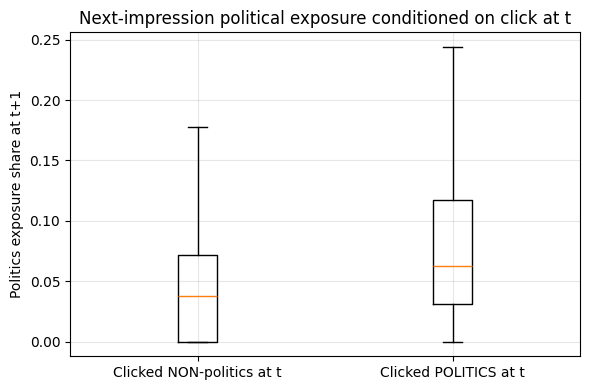

Mean next exposure | click_nonpol: 0.05045535394346972
Mean next exposure | click_pol: 0.09415942669193744
Difference (pol - nonpol): 0.04370407274846772
n_nonpol: 22083 n_pol: 1069


In [48]:
df = imp2.dropna(subset=["exposure_share_t+1"]).copy()

vals0 = df[df["clicked_politics"] == 0]["exposure_share_t+1"].values
vals1 = df[df["clicked_politics"] == 1]["exposure_share_t+1"].values

plt.figure(figsize=(6,4))
plt.boxplot(
    [vals0, vals1],
    tick_labels=["Clicked NON-politics at t", "Clicked POLITICS at t"],
    showfliers=False
)
plt.ylabel("Politics exposure share at t+1")
plt.title("Next-impression political exposure conditioned on click at t")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean next exposure | click_nonpol:", np.mean(vals0))
print("Mean next exposure | click_pol:", np.mean(vals1))
print("Difference (pol - nonpol):", np.mean(vals1) - np.mean(vals0))
print("n_nonpol:", len(vals0), "n_pol:", len(vals1))


The boxplot shows the distribution shifts upward, not only a few extreme cases.  

In [50]:
rng = np.random.default_rng(42)

def bootstrap_delta(df, n_boot=300, col="next_exposure_share"):
    base = df.dropna(subset=[col]).copy()
    idx = base.index.to_numpy()
    deltas = []
    for _ in range(n_boot):
        samp_idx = rng.choice(idx, size=len(idx), replace=True)
        samp = base.loc[samp_idx]
        a = samp.loc[samp["clicked_politics"]==1, col]
        b = samp.loc[samp["clicked_politics"]==0, col]
        if len(a) == 0 or len(b) == 0:
            continue
        deltas.append(float(a.mean() - b.mean()) * 100)
    deltas = np.array(deltas)
    mean = float(deltas.mean())
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    return mean, float(lo), float(hi)

mean_pp, lo, hi = bootstrap_delta(imp2, n_boot=300, col="next_exposure_share")
print(f"Bootstrap Δ (pp) overall: mean={mean_pp:+.2f}, 95% CI=[{lo:+.2f}, {hi:+.2f}]")


Bootstrap Δ (pp) overall: mean=+4.41, 95% CI=[+3.70, +5.11]


**Uncertainty (bootstrap).**  
To quantify uncertainty in the one-step association Δ = E[next exposure | political click] − E[next exposure | non-political click],
I bootstrap resample the impression rows (300 samples).  
The estimated effect is Δ ≈ +4.41 percentage points with a 95% bootstrap CI of [+3.70, +5.11].  
Since the interval is entirely above 0, the positive one-step association is robust in the logged data (though still observational, not causal).


### One-step effect split by user group (engaged vs others)

In [11]:
res_eng = summarize_one_step(imp2[imp2["is_engaged_user"]==True], "next_exposure_share")
res_oth = summarize_one_step(imp2[imp2["is_engaged_user"]==False], "next_exposure_share")

print_conclusion(res_eng, "next_exposure_share", "Engaged users (>=3 political clicks in TRAIN)")
print_conclusion(res_oth, "next_exposure_share", "Other users")


[Engaged users (>=3 political clicks in TRAIN)]
- E[next_exposure_share | political click]    = 0.0924
- E[next_exposure_share | no political click] = 0.0738
- Δ = +1.86 percentage points
Conclusion: Political clicks are followed by *higher* political exposure next impression (reinforcement signal).

[Other users]
- E[next_exposure_share | political click]    = 0.0942
- E[next_exposure_share | no political click] = 0.0503
- Δ = +4.39 percentage points
Conclusion: Political clicks are followed by *higher* political exposure next impression (reinforcement signal).



Interpretation of group differences:
- Engaged users have a **higher baseline political environment** even after non-political clicks (7.38%),
  so the observed “jump” after a political click is smaller.
- For other users, a political click is a stronger “signal”, and the next impression shifts more.

### Event-aligned trajectories (steps 0–3)

I split impressions into two starting conditions at time t:
(1) impressions where a political item was clicked (`clicked_politics=1`), and
(2) impressions with no political click (`clicked_politics=0`).
I then align each user’s subsequent impressions (t+1, t+2, t+3) and compute averages.


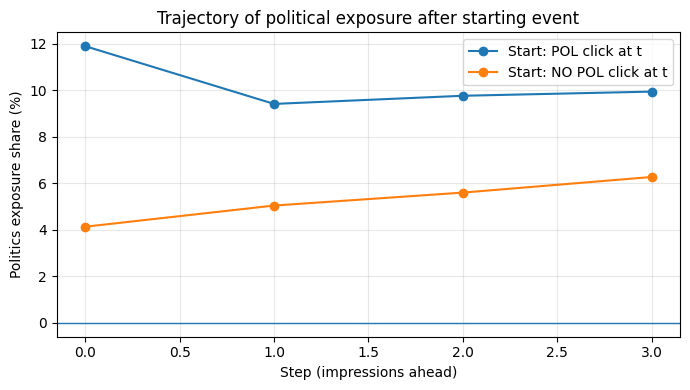

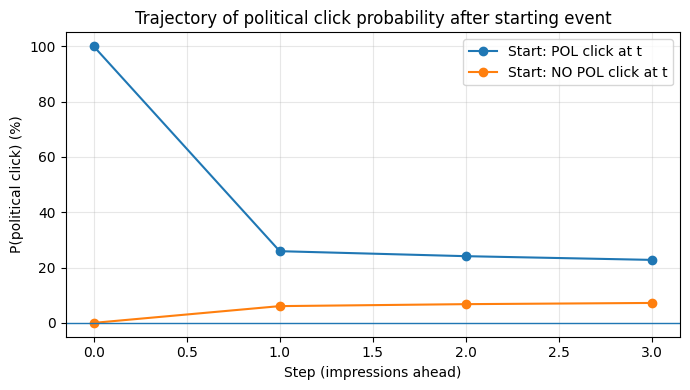

,start_pol,step,mean_exposure,mean_click_pol,n
0,False,0,0.041358,0.000000,68799
1,False,1,0.050455,0.060590,22083
2,False,2,0.056028,0.067710,7990
3,False,3,0.062744,0.072072,3219
4,True,0,0.118995,1.000000,4353
5,True,1,0.094159,0.259121,1069
6,True,2,0.097666,0.241071,336
7,True,3,0.099452,0.227642,123


In [23]:
MAX_K = 3  

df = imp2.dropna(subset=["time_dt"]).sort_values(["user_id", "time_dt"]).copy()

rows = []
base_cols = ["user_id", "time_dt", "exposure_share", "clicked_politics", "is_engaged_user"]
base = df[base_cols].copy()

for s in range(0, MAX_K + 1):
    tmp = base.copy()
    tmp["step"] = s
    tmp["exposure_s"] = df.groupby("user_id")["exposure_share"].shift(-s).values
    tmp["click_pol_s"] = df.groupby("user_id")["clicked_politics"].shift(-s).values
    rows.append(tmp)

panel = pd.concat(rows, ignore_index=True)

panel = panel.dropna(subset=["exposure_s", "click_pol_s"]).copy()

# Define two starting conditions based on step 0:
#  - start_pol: sequences where clicked_politics at step 0 == 1
#  - start_nonpol: sequences where clicked_politics at step 0 == 0
panel["start_pol"] = (panel["clicked_politics"] == 1)

# Aggregate: average exposure and average political-click probability by step and start condition
agg = (
    panel.groupby(["start_pol", "step"])
    .agg(mean_exposure=("exposure_s", "mean"),
         mean_click_pol=("click_pol_s", "mean"),
         n=("exposure_s", "size"))
    .reset_index()
)

plt.figure(figsize=(7,4))
for flag, lab in [(True, "Start: POL click at t"), (False, "Start: NO POL click at t")]:
    d = agg[agg["start_pol"] == flag]
    plt.plot(d["step"], d["mean_exposure"]*100, marker="o", label=lab)

plt.axhline(0, linewidth=1)
plt.xlabel("Step (impressions ahead)")
plt.ylabel("Politics exposure share (%)")
plt.title("Trajectory of political exposure after starting event")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
for flag, lab in [(True, "Start: POL click at t"), (False, "Start: NO POL click at t")]:
    d = agg[agg["start_pol"] == flag]
    plt.plot(d["step"], d["mean_click_pol"]*100, marker="o", label=lab)

plt.axhline(0, linewidth=1)
plt.xlabel("Step (impressions ahead)")
plt.ylabel("P(political click) (%)")
plt.title("Trajectory of political click probability after starting event")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(agg)


**Exposure trajectory:** After a political click, the share of political candidates remains much higher in the next impressions (~10%) than after a non-political start (~5–6%), indicating a sustained increase in political exposure following political interaction.

**Click trajectory:** After a political click, the probability of another political click in subsequent impressions is also substantially higher (~23–26% vs ~6–8%). This shows behavioral persistence that, together with the higher exposure, is consistent with a short-term reinforcement / feedback-loop dynamic in the logs.


#### Further Interpretation

The “Start: POL click at t” group is defined by construction to have a political click at step 0 (100%). In subsequent impressions (steps 1–3), the probability of another political click drops to ~23–26%, showing that political clicking is not guaranteed to persist for most impressions.
This reduced persistence can be related to the small decline in political exposure from step 0 to steps ahead in the same group. (Having less political options available made people click less? or eventually people clicking less made less political options available?)

Importantly, exposure remains high (~10%) across steps 1–3 compared to the “Start: NO POL click” group (~5–6%), suggesting that a political click is followed by a more political recommendation environment for several subsequent impressions.

In the “Start: NO POL click at t” group, both political exposure and political click probability increase slightly over steps 1–3. However, the logs do not allow us to separate whether higher exposure drives more clicks or whether user interest drives exposure changes (or both), so I interpret the pattern as an association consistent with a feedback loop, not a causal claim.

### Feedback-loop test with intermediate clicks (windowed analysis)

To incorporate *all clicks between* t and t+k, I count the number of political clicks in the window [t .. t+k−1] and measure political exposure at t+k.


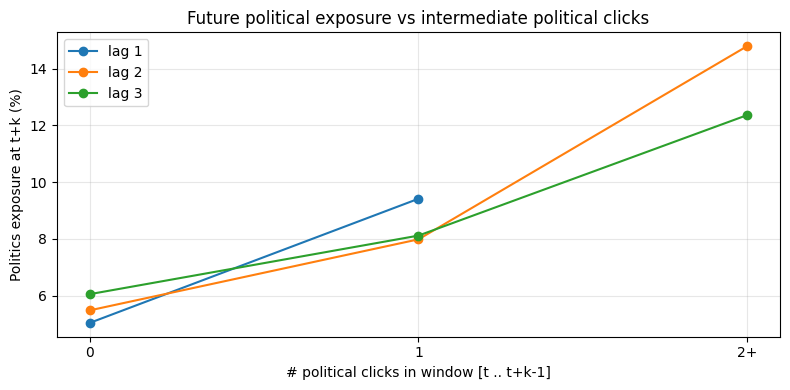

,bucket,mean,count,lag
0,0,0.050455,22083,1
1,1,0.094159,1069,1
2,0,0.054869,7601,2
3,1,0.079870,644,2
4,2+,0.147882,81,2
5,0,0.060571,2919,3
6,1,0.081188,351,3
7,2+,0.123607,72,3


In [25]:
df = imp2.dropna(subset=["time_dt"]).sort_values(["user_id", "time_dt"]).copy()

for k in range(1, MAX_K+1):
    if f"exposure_share_t+{k}" not in df.columns:
        df[f"exposure_share_t+{k}"] = df.groupby("user_id")["exposure_share"].shift(-k)

for k in range(0, MAX_K):  
    if f"click_pol_t+{k}" not in df.columns:
        df[f"click_pol_t+{k}"] = df.groupby("user_id")["clicked_politics"].shift(-k)

results = []

for k in range(1, MAX_K+1):
    # number of political clicks in intermediate window t..t+k-1
    click_cols = [f"click_pol_t+{j}" for j in range(0, k)]
    df_k = df.dropna(subset=[f"exposure_share_t+{k}"] + click_cols).copy()
    df_k["pol_clicks_window"] = df_k[click_cols].sum(axis=1)

    # bucket 0 / 1 / 2+
    df_k["bucket"] = pd.cut(
        df_k["pol_clicks_window"],
        bins=[-0.1, 0.1, 1.1, 999],
        labels=["0", "1", "2+"]
    )

    g = (
        df_k.groupby("bucket", observed=True)[f"exposure_share_t+{k}"]
        .agg(["mean", "count"])
        .reset_index()
    )
    g["lag"] = k
    results.append(g)

res = pd.concat(results, ignore_index=True)

plt.figure(figsize=(8,4))
for k in range(1, MAX_K+1):
    d = res[res["lag"] == k]
    plt.plot(d["bucket"].astype(str), d["mean"]*100, marker="o", label=f"lag {k}")

plt.xlabel("# political clicks in window [t .. t+k-1]")
plt.ylabel("Politics exposure at t+k (%)")
plt.title("Future political exposure vs intermediate political clicks")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(res)


Results show a clear monotonic relationship: more political clicking in the intermediate window is associated with higher political exposure later.

- **k=1:** 0 clicks → 5.05% vs 1 click → 9.42% (Δ ≈ +4.37 pp)
- **k=2:** 0 → 5.49%, 1 → 7.99%, 2+ → 14.79% (0→2+ ≈ +9.30 pp)
- **k=3:** 0 → 6.06%, 1 → 8.12%, 2+ → 12.36% (0→2+ ≈ +6.30 pp)

Interpretation: repeated political interaction is followed by a substantially more political candidate set in future impressions, consistent with a short-term reinforcement / feedback-loop dynamic. Buckets with 2+ clicks have smaller sample sizes (e.g., 81 at k=2; 72 at k=3), so those estimates are suggestive but align with the same trend.


### Windowed reinforcement test (mean ± 95% CI)

Error bars show 95% confidence intervals.

,bucket,mean,std,count,lag,se,ci95
0,0,5.045535,6.736943,22083,1,0.045335,0.088857
1,1,9.415943,11.708287,1069,1,0.358100,0.701876
2,0,5.486940,7.013822,7601,2,0.080449,0.157680
3,1,7.987035,8.950744,644,2,0.352709,0.691309
4,2+,14.788244,20.350913,81,2,2.261213,4.431977
5,0,6.057129,7.358268,2919,3,0.136194,0.266941
6,1,8.118760,9.290594,351,3,0.495895,0.971955
7,2+,12.360710,18.797358,72,3,2.215290,4.341968


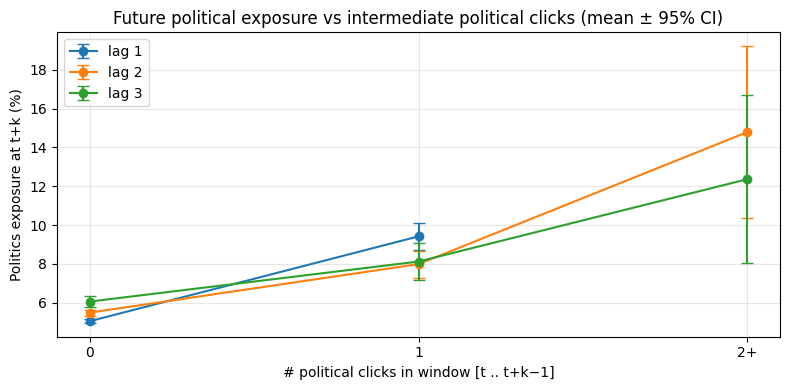

In [ ]:
rows = []

for k in range(1, MAX_K + 1):
    click_cols = [f"click_pol_t+{j}" for j in range(0, k)]
    needed = [f"exposure_share_t+{k}"] + click_cols
    
    df_k = df.dropna(subset=needed).copy()
    df_k["pol_clicks_window"] = df_k[click_cols].sum(axis=1)

    df_k["bucket"] = pd.cut(
        df_k["pol_clicks_window"],
        bins=[-0.1, 0.1, 1.1, 999],
        labels=["0", "1", "2+"]
    )

    g = (
        df_k.groupby("bucket", observed=True)[f"exposure_share_t+{k}"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    g["lag"] = k

    g["se"] = g["std"] / np.sqrt(g["count"])
    g["ci95"] = 1.96 * g["se"]
    rows.append(g)

res_ci = pd.concat(rows, ignore_index=True)

res_ci_display = res_ci.copy()
for c in ["mean", "std", "se", "ci95"]:
    res_ci_display[c] = res_ci_display[c] * 100

display(res_ci_display.sort_values(["lag", "bucket"]))


bucket_order = ["0", "1", "2+"]
x = np.arange(len(bucket_order))

plt.figure(figsize=(8, 4))

for k in range(1, MAX_K + 1):
    d = res_ci[res_ci["lag"] == k].copy()
    d["bucket"] = d["bucket"].astype(str)
    d = d.set_index("bucket").reindex(bucket_order)

    y = d["mean"].values * 100
    yerr = d["ci95"].values * 100 
    
    plt.errorbar(
        x, y, yerr=yerr,
        marker="o",
        capsize=4,
        label=f"lag {k}"
    )

plt.xticks(x, bucket_order)
plt.xlabel("# political clicks in window [t .. t+k−1]")
plt.ylabel("Politics exposure at t+k (%)")
plt.title("Future political exposure vs intermediate political clicks (mean ± 95% CI)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Across lags k=2 and k=3, political exposure at t+k increases with the number of political clicks in the preceding window:

- **k=2:** 0 → 5.49% (±0.16, n=7601), 1 → 7.99% (±0.69, n=644), 2+ → 14.79% (±4.43, n=81)
- **k=3:** 0 → 6.06% (±0.27, n=2919), 1 → 8.12% (±0.97, n=351), 2+ → 12.36% (±4.34, n=72)

This indicates that political clicks are followed by higher political exposure in subsequent impressions, consistent with a short-horizon reinforcement/feedback-loop dynamic in the logs. Differences for 0 vs 1 click are supported by large sample sizes and tight CIs; the 2+ bucket suggests an even stronger effect but is less precise due to smaller n.

### Within-user version (reduces confounding)

Users differ in baseline political exposure. To reduce that, I subtract each user’s mean exposure:

exposure_dev = exposure_share − user_mean_exposure

Then repeat the one-step effect on `next_exposure_dev`.

In [13]:
user_mean_exposure = imp2.groupby("user_id")["exposure_share"].transform("mean")
imp2["exposure_dev"] = imp2["exposure_share"] - user_mean_exposure
imp2["next_exposure_dev"] = imp2.groupby("user_id")["exposure_dev"].shift(-1)

within_overall = summarize_one_step(imp2, "next_exposure_dev")
within_eng = summarize_one_step(imp2[imp2["is_engaged_user"]==True], "next_exposure_dev")
within_oth = summarize_one_step(imp2[imp2["is_engaged_user"]==False], "next_exposure_dev")

print_conclusion(within_overall, "next_exposure_dev", "Overall (within-user)")
print_conclusion(within_eng, "next_exposure_dev", "Engaged (within-user)")
print_conclusion(within_oth, "next_exposure_dev", "Others (within-user)")


[Overall (within-user)]
- E[next_exposure_dev | political click]    = -0.0036
- E[next_exposure_dev | no political click] = 0.0059
- Δ = -0.95 percentage points
Conclusion: Political clicks are followed by *lower* political exposure next impression (reverse effect).

[Engaged (within-user)]
- E[next_exposure_dev | political click]    = -0.0072
- E[next_exposure_dev | no political click] = 0.0070
- Δ = -1.42 percentage points
Conclusion: Political clicks are followed by *lower* political exposure next impression (reverse effect).

[Others (within-user)]
- E[next_exposure_dev | political click]    = -0.0034
- E[next_exposure_dev | no political click] = 0.0059
- Δ = -0.93 percentage points
Conclusion: Political clicks are followed by *lower* political exposure next impression (reverse effect).



The apparent reinforcement in the raw analysis may be largely explained by who is clicking politics and when (session context), rather than a strong immediate “algorithm pushes more politics after a click” effect. When we control for each user’s baseline exposure, the immediate next impression becomes slightly less political on average.

These results are not contradictory: they reflect different questions. Earlier analyses show a strong *between-user* difference - politically engaged users experience a substantially higher baseline level of political exposure. 

The within-user (one-step) test asks a narrower question: whether the *immediately next* impression becomes more political right after a political click for the same user. Here, the effect is small and slightly negative, suggesting that short-term diversification or session dynamics may dominate at the next-impression level. Importantly, the windowed analysis over k=2–3 impressions still shows that repeated political clicking in a short window is associated with higher political exposure later, indicating that reinforcement may operate as a gradual, multi-step accumulation rather than an instantaneous jump.


Interestingly, the within-user one-step effect is slightly negative: after a political click, the next impression contains marginally *less* political content than the same user’s baseline, while after a non-political click it contains marginally *more*. This pattern is inconsistent with a naive “immediate amplification” mechanism and is more consistent with short-term balancing forces such as diversification (avoiding consecutive same-topic exposure), candidate-pool constraints (politics is a small fraction of content), or session-context shifts. Importantly, this does not contradict the longer-horizon results: reinforcement may still emerge gradually through repeated interactions and sustained baseline differences rather than an immediate next-impression jump.


Socially, this may be even more concerning: rather than a sudden, obvious shift, users can be gradually surrounded by the content they engage with. Because the change is subtle and accumulates over time, it may be harder for users to notice - and therefore harder to question or correct.

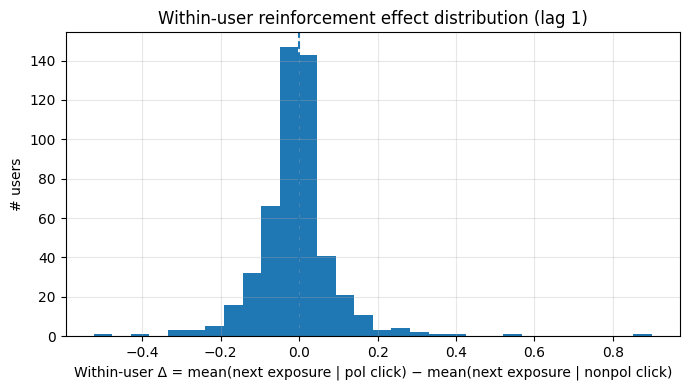

Users included: 503
Mean Δ: -0.009396651867232543
Median Δ: -0.00889395274731964
Share with Δ > 0: 0.4294234592445328


In [49]:
df = imp2.dropna(subset=["exposure_share_t+1"]).copy()

per_user = (
    df.groupby(["user_id", "clicked_politics"])["exposure_share_t+1"]
    .mean()
    .unstack()
)

per_user = per_user.dropna(subset=[0, 1]).copy()
per_user["delta"] = per_user[1] - per_user[0]

plt.figure(figsize=(7,4))
plt.hist(per_user["delta"].values, bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Within-user Δ = mean(next exposure | pol click) − mean(next exposure | nonpol click)")
plt.ylabel("# users")
plt.title("Within-user reinforcement effect distribution (lag 1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Users included:", len(per_user))
print("Mean Δ:", per_user["delta"].mean())
print("Median Δ:", per_user["delta"].median())
print("Share with Δ > 0:", (per_user["delta"] > 0).mean())


**Within-user effect distribution (lag 1).**  
For each user was compute Δ = mean(next political exposure | political click) − mean(next political exposure | non-political click).
Positive Δ indicates user-level reinforcement, negative Δ indicates a short-term balancing effect.  
Across 503 users with both click types, the mean Δ is −0.94 percentage points (median −0.89 pp), and 42.9% of users have Δ > 0.  
This suggests strong heterogeneity: while many users show reinforcement, the average immediate within-user effect is slightly negative, consistent with short-term diversification/balancing in the feed.


------------------------------------

### **Qualitative sanity check (sample user timelines).**  

In [42]:
N_USERS = 6      
MAX_ROWS_PER_USER = 12

COL_TIME = "time_dt"                
COL_USER = "user_id"
COL_EXPO = "exposure_share"          
COL_NEXT = "exposure_share_t+1"      
COL_CLICK_POL = "clicked_politics"   

imp_show = imp2.dropna(subset=[COL_NEXT]).copy()

imp_show = imp_show[imp_show[COL_USER].isin(engaged_users)].copy()

user_event_counts = imp_show.groupby(COL_USER)[COL_CLICK_POL].agg(["sum", "count"])
user_event_counts["nonpol"] = user_event_counts["count"] - user_event_counts["sum"]
eligible_users = user_event_counts[(user_event_counts["sum"] >= 2) & (user_event_counts["nonpol"] >= 2)].index

if len(eligible_users) < N_USERS:
    eligible_users = (
        imp_show.groupby(COL_USER).size().sort_values(ascending=False).head(N_USERS).index
    )
else:
    eligible_users = list(eligible_users)[:N_USERS]

timeline = (
    imp_show[imp_show[COL_USER].isin(eligible_users)]
    .sort_values([COL_USER, COL_TIME])
    .groupby(COL_USER)
    .head(MAX_ROWS_PER_USER)
    [[COL_USER, COL_TIME, COL_CLICK_POL, COL_EXPO, COL_NEXT]]
    .copy()
)

timeline["event"] = np.where(
    timeline[COL_CLICK_POL].astype(int) == 1,
    "CLICK_POL at t  →  next exposure",
    "CLICK_NONPOL at t → next exposure"
)

timeline[COL_EXPO] = timeline[COL_EXPO].astype(float).round(3)
timeline[COL_NEXT] = timeline[COL_NEXT].astype(float).round(3)

delta_per_user = (
    timeline.groupby([COL_USER, COL_CLICK_POL])[COL_NEXT]
    .mean()
    .unstack(fill_value=np.nan)
)
delta_per_user["delta(next|pol - next|nonpol)"] = delta_per_user.get(1, np.nan) - delta_per_user.get(0, np.nan)
delta_per_user = delta_per_user.rename(columns={0: "mean next exposure | click_nonpol", 1: "mean next exposure | click_pol"})
delta_per_user = delta_per_user.round(3).reset_index()

print("Sample timeline rows:", timeline.shape[0], "for users:", len(eligible_users))
display(delta_per_user)
display(timeline)


Sample timeline rows: 34 for users: 6


clicked_politics,user_id,mean next exposure | click_nonpol,mean next exposure | click_pol,delta(next|pol - next|nonpol)
0,U18677,0.046,0.076,0.030
1,U42943,0.045,0.071,0.026
2,U54826,0.083,0.100,0.017
3,U57047,0.040,NaN,NaN
4,U8907,0.020,0.067,0.047
5,U93804,0.035,NaN,NaN


,user_id,time_dt,clicked_politics,exposure_share,exposure_share_t+1,event
impression_id,,,,,,
31276,U18677,2019-11-15 09:06:13,0,0.047,0.037,CLICK_NONPOL at t → next exposure
71011,U18677,2019-11-15 09:35:43,0,0.037,0.091,CLICK_NONPOL at t → next exposure
5606,U18677,2019-11-15 12:22:33,1,0.091,0.076,CLICK_POL at t → next exposure
5013,U18677,2019-11-15 13:27:21,0,0.076,0.055,CLICK_NONPOL at t → next exposure
54831,U18677,2019-11-15 14:53:25,0,0.055,0.000,CLICK_NONPOL at t → next exposure
26341,U42943,2019-11-15 06:09:01,0,0.053,0.049,CLICK_NONPOL at t → next exposure
40167,U42943,2019-11-15 10:17:22,1,0.049,0.071,CLICK_POL at t → next exposure
18005,U42943,2019-11-15 10:57:09,0,0.071,0.037,CLICK_NONPOL at t → next exposure
17104,U42943,2019-11-15 11:08:56,0,0.037,0.045,CLICK_NONPOL at t → next exposure



To make the aggregate results more interpretable, I inspected a small sample of users and their impression timelines. For users who had both political and non-political clicks, the mean political exposure at the next impression was higher after political clicks than after non-political clicks (e.g., Δ≈+1.7 to +4.7 percentage points in the sample). Some sampled users had no political clicks, highlighting that political engagement is sparse for many users. This qualitative check aligns with the aggregate one-step/windowed analyses but is only illustrative due to the small sample size.


## Notebook 05 — Conclusions

**What I tested.** Using DEV impression timelines, I tested whether political interaction is followed by higher *future* political exposure in the logged candidate lists (observational evidence, not a controlled experiment).

**Key findings.**
- **Politics is a small slice of the feed.** Political items are ~5% of exposures and ~4% of clicks, so politics exists in the logs but is not the dominant category.
- **Overall one-step association is positive.** After a political click at time *t*, the next impression (*t+1*) has higher political exposure on average (Δ ≈ +4–5 pp). The bootstrap CI being fully above 0 suggests this association is robust in this sample.
- **Event-aligned trajectories show a higher-exposure regime.** Sessions that start with a political click begin at much higher political exposure and remain above the “non-political start” trajectory for the next few impressions.
- **Windowed signal.** More political clicks inside a short window \([t..t+k-1]\) are associated with higher political exposure at \(t+k\), though the “2+ clicks” buckets have small counts (higher uncertainty).
- **Within-user results differ (informative).** After removing each user’s baseline exposure, the immediate next-impression change becomes slightly negative on average, suggesting the strongest reinforcement signal is less about an instant one-step push and more about stable user-level baselines and longer-term personalization.

**Limitations.**
- Observational (no causal proof).
- Political labeling here is binary (politics vs non-politics), not ideology.
- Many users have short timelines, limiting long-lag analyses.


Overall, political engagement is associated with higher political exposure in the logs, but the immediate within-user step is not strongly positive, the stronger signal appears to be stable, longer-term personalization.

## Next notebook (Notebook 06 — Ideology labeling + validation)

MIND does not reliably expose publisher/outlet metadata, so I cannot directly map articles to known left/center/right outlets.

To study *political orientation bias* (not just “politics vs non-politics”), I will:

1) Use a pretrained political-leaning classifier to label each political article (title + abstract) as **left / center / right**.  
2) Run a small manual audit (≈30–50 items) to sanity-check label quality and report typical errors.  
3) Re-run exposure/click analyses using ideology labels to test whether users are increasingly exposed to the same leaning they interact with.

This provides a justified foundation for later fairness + explainability steps (e.g., re-ranking to reduce over-concentration, and XAI tools to explain what drives labels and rankings).
